# Smart Energy Consumption Forecasting & Anomaly Detection

## Part A: Exploratory Data Analysis and Feature Engineering

This notebook performs exploratory data analysis (EDA), feature engineering, and statistical analysis on the Appliances Energy Prediction dataset. The goal is to understand patterns in energy consumption and prepare features for predictive modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset is loaded and initial inspection is performed to understand its structure.

In [17]:
df = pd.read_csv("energydata_complete.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Dataset Overview

This dataset contains energy consumption data along with environmental and temporal features recorded at 10-minute intervals.

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [21]:
df['date'] = pd.to_datetime(df['date'])

# Feature extraction (NEEDED for plots)
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

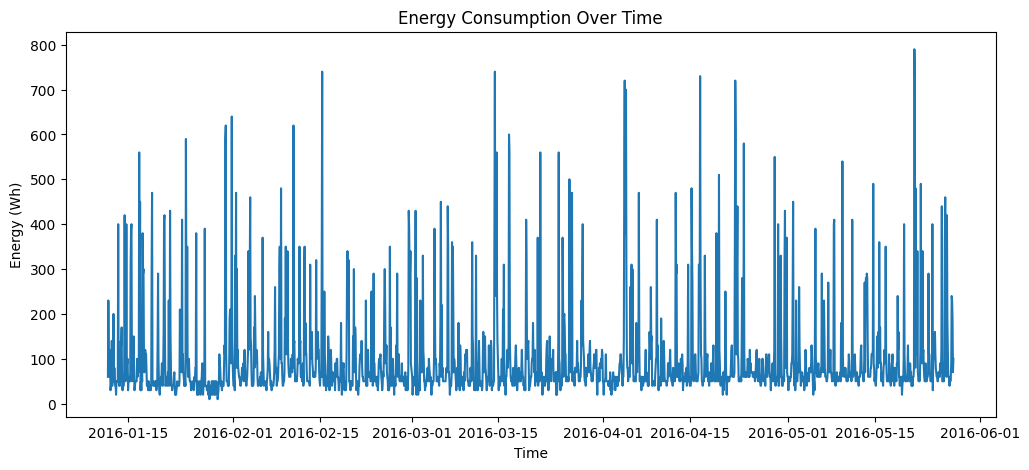

In [22]:
df_sample = df.iloc[::10]  # sampling to speed up

plt.figure(figsize=(12,5))
plt.plot(df_sample['date'], df_sample['Appliances'])
plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Energy (Wh)")
plt.show()

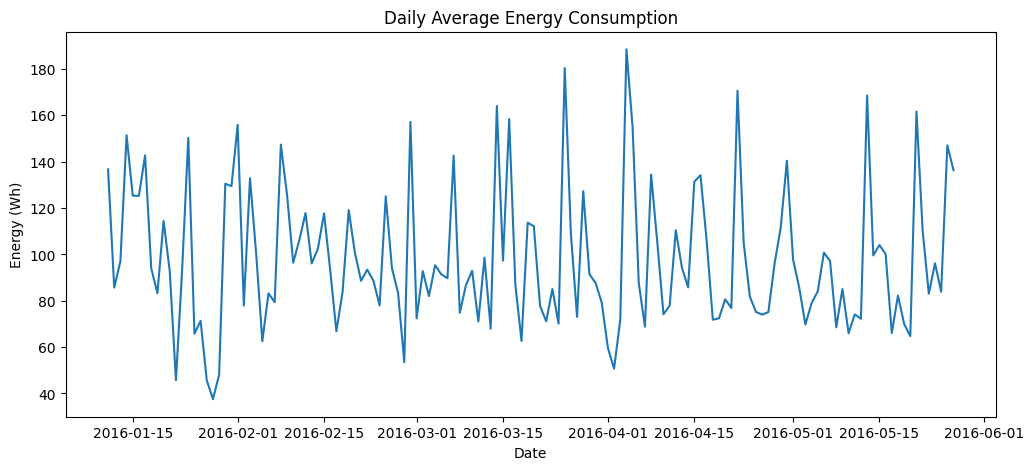

In [11]:
df['date'] = pd.to_datetime(df['date'])  # ensure datetime

df = df.set_index('date') 

df_daily = df.resample('D').mean()

plt.figure(figsize=(12,5))
plt.plot(df_daily.index, df_daily['Appliances'])
plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy (Wh)")
plt.show()

### 2. Energy Consumption by Hour of Day

Energy consumption varies significantly across different hours of the day, with higher values typically observed during daytime and evening hours. This pattern reflects human activity cycles, such as cooking, working, and appliance usage. The variation within each hour also indicates inconsistent usage patterns. This suggests that the hour of day is a crucial feature for modeling energy consumption.

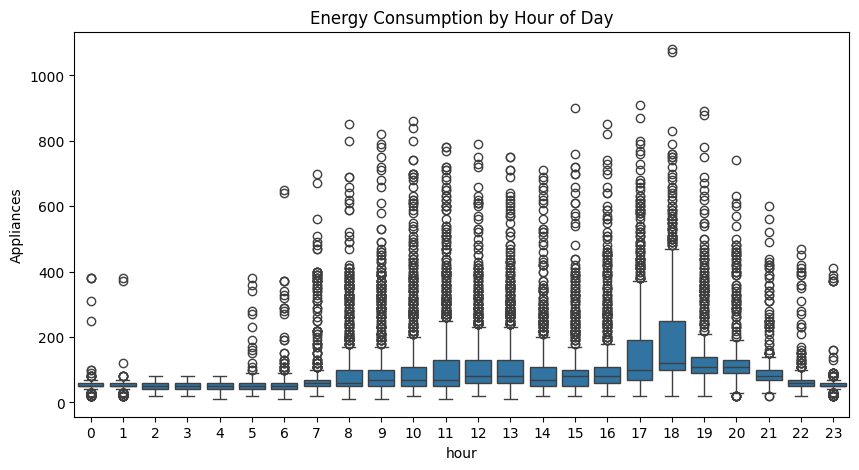

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x='hour', y='Appliances', data=df)
plt.title("Energy Consumption by Hour of Day")
plt.show()

### 3. Energy Consumption by Day of Week

The energy consumption shows variation across different days of the week, indicating possible weekly usage patterns. Some days exhibit slightly higher median consumption, which may be due to differences in occupancy or lifestyle behavior. However, the variation is not extremely large, suggesting relatively consistent usage. Including day-of-week as a feature may still help capture subtle behavioral differences.

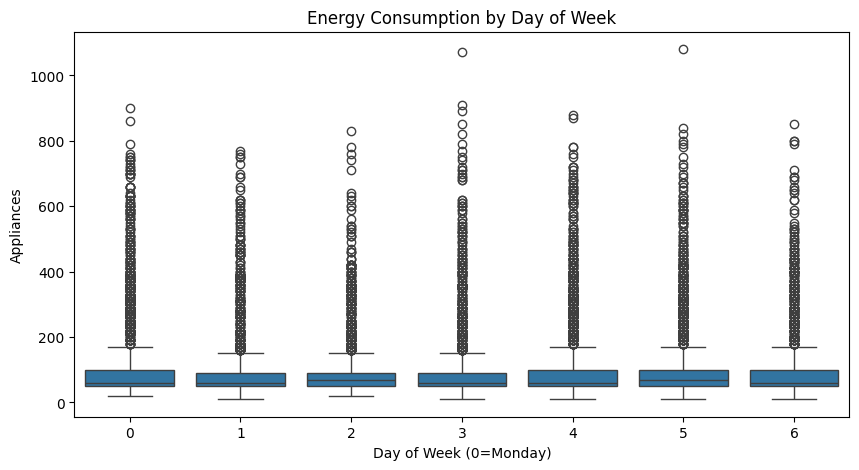

In [20]:
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.dayofweek

plt.figure(figsize=(10,5))
sns.boxplot(x='day_of_week', y='Appliances', data=df)
plt.title("Energy Consumption by Day of Week")
plt.xlabel("Day of Week (0=Monday)")
plt.show()

### 4. Rolling Mean of Energy Consumption

The rolling mean smooths short-term fluctuations in energy consumption and helps reveal the underlying trend. This makes it easier to identify consistent patterns that may not be visible in raw data. The presence of smooth variations indicates predictable short-term behavior. Rolling statistics are useful for capturing local trends and improving model stability.

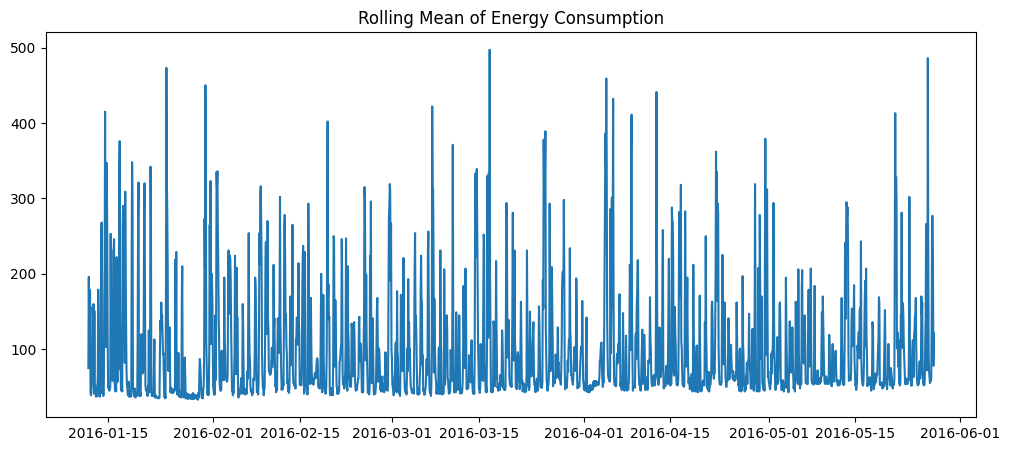

In [24]:
df['rolling_mean_10'] = df['Appliances'].rolling(window=10).mean()

df_sample = df.iloc[::10]

plt.figure(figsize=(12,5))
plt.plot(df_sample['date'], df_sample['rolling_mean_10'])
plt.title("Rolling Mean of Energy Consumption")
plt.show()

### 5. Distribution of Energy Consumption

The distribution of energy consumption appears to be right-skewed, with most values concentrated at lower levels and a few extreme high values. This indicates that high energy usage events are relatively rare but significant. Such skewness can impact model performance, especially for algorithms sensitive to distribution. Understanding this distribution is important for selecting appropriate modeling techniques.

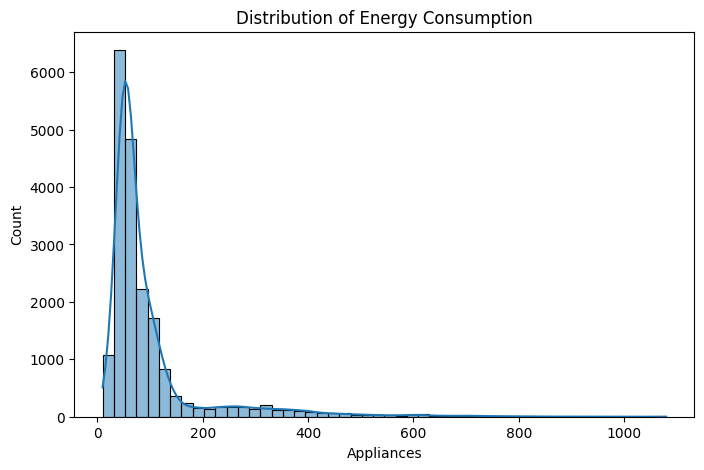

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['Appliances'], bins=50, kde=True)
plt.title("Distribution of Energy Consumption")
plt.show()

### 6. Boxplot of Energy Consumption

The boxplot highlights the presence of several outliers in energy consumption, indicating occasional extreme usage values. These outliers may be caused by unusual events or peak activity periods. Such extreme values can influence model performance and may require careful handling. Identifying outliers is important for building robust predictive models.

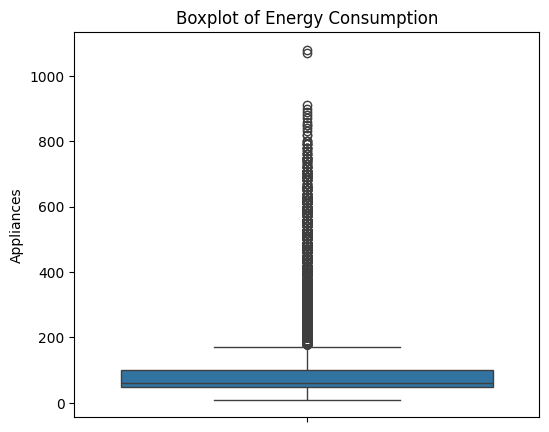

In [26]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['Appliances'])
plt.title("Boxplot of Energy Consumption")
plt.show()

### 7. Temperature vs Energy Consumption

The scatter plot shows a positive relationship between temperature and energy consumption, suggesting that energy usage increases as temperature rises. This may be due to increased cooling demand during warmer conditions. However, the relationship is not strictly linear, indicating the influence of additional factors. Temperature is likely a significant feature for predicting energy consumption.

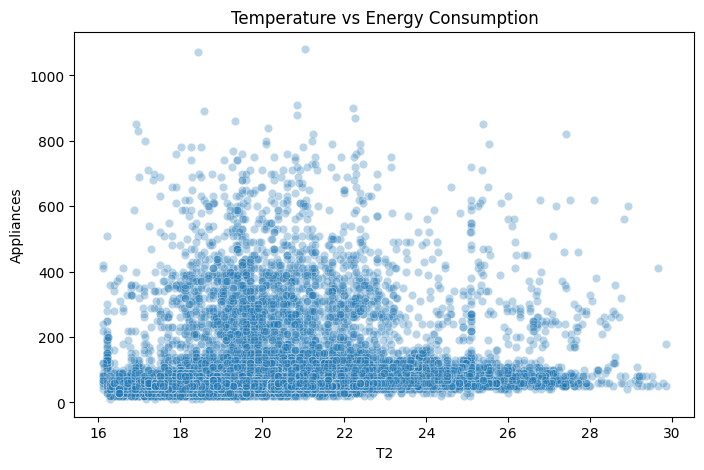

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='T2', y='Appliances', data=df, alpha=0.3)
plt.title("Temperature vs Energy Consumption")
plt.show()

### 8. Humidity vs Energy Consumption

The relationship between humidity and energy consumption appears to be weaker compared to temperature. While some variation exists, no strong trend is observed. This suggests that humidity alone may not be a primary driver of energy usage. However, it could still contribute in combination with other environmental factors.

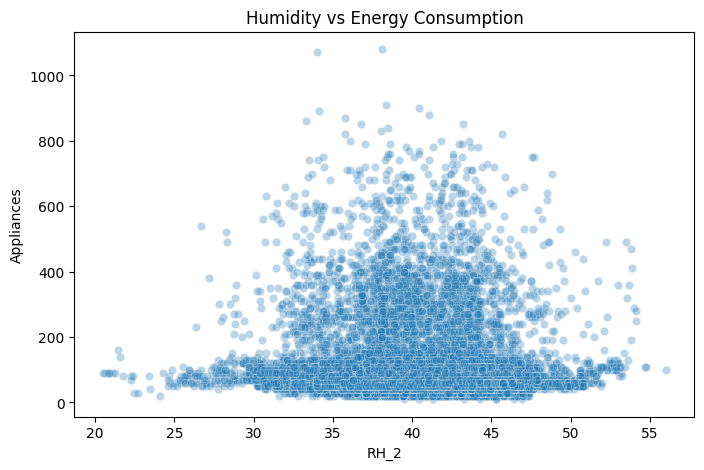

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='RH_2', y='Appliances', data=df, alpha=0.3)
plt.title("Humidity vs Energy Consumption")
plt.show()

### 9. Correlation Heatmap

The correlation heatmap provides an overview of linear relationships between features. Temperature-related features show moderate correlation with energy consumption, indicating their relevance. However, many variables exhibit low correlation, suggesting the presence of non-linear relationships. This highlights the need for additional analysis methods such as mutual information.

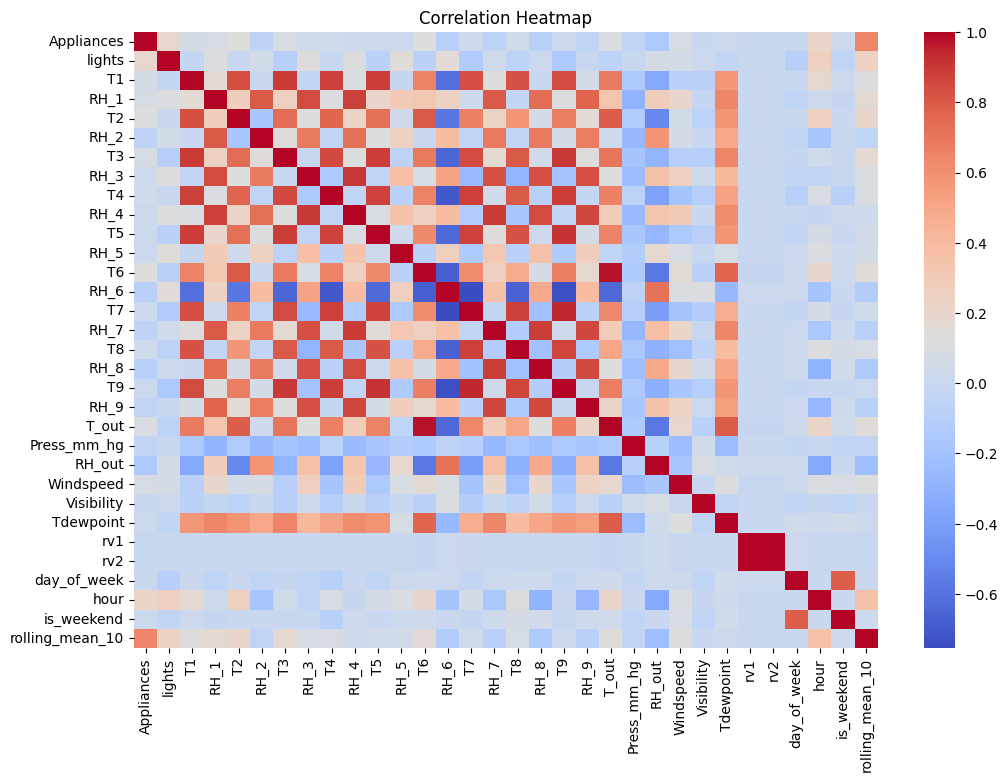

In [29]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 10. Lag Plot of Energy Consumption

The lag plot shows a strong relationship between previous and current energy values, indicating temporal dependency in the data. This suggests that past energy consumption significantly influences future values. Such behavior is typical in time-series data and justifies the use of lag features. This insight supports the use of sequence-based models and time-aware feature engineering.

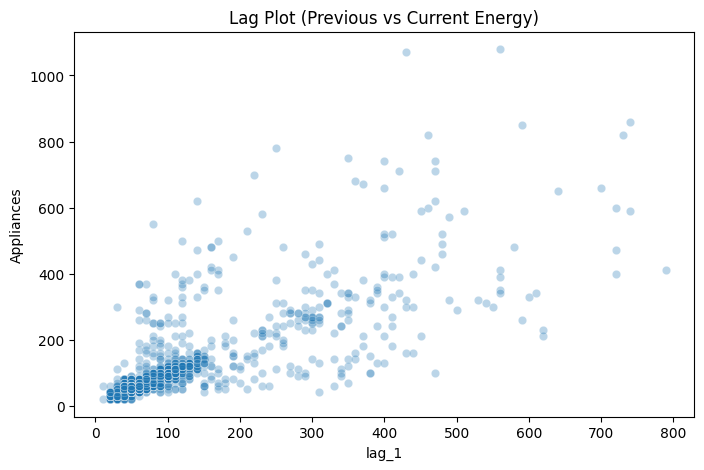

In [30]:
df['lag_1'] = df['Appliances'].shift(1)

df_lag = df[['lag_1', 'Appliances']].dropna().iloc[::10]

plt.figure(figsize=(8,5))
sns.scatterplot(x='lag_1', y='Appliances', data=df_lag, alpha=0.3)
plt.title("Lag Plot (Previous vs Current Energy)")
plt.show()